In [1]:
import pandas as pd

df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df['Sex'].value_counts()
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

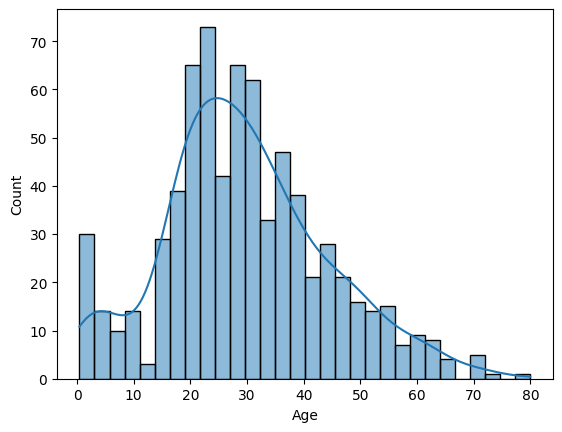

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Age'], bins=30, kde=True)
plt.show()

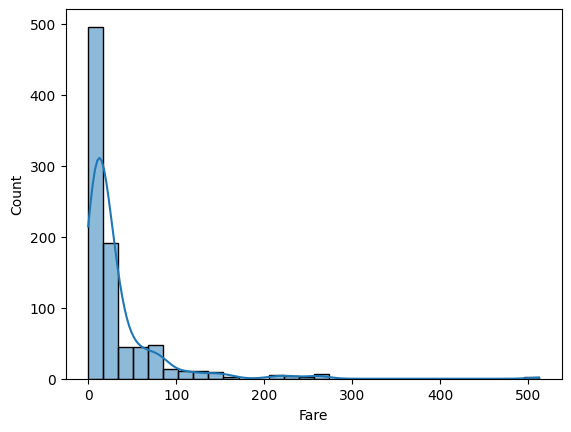

In [7]:
sns.histplot(df['Fare'], bins=30, kde=True)
plt.show()

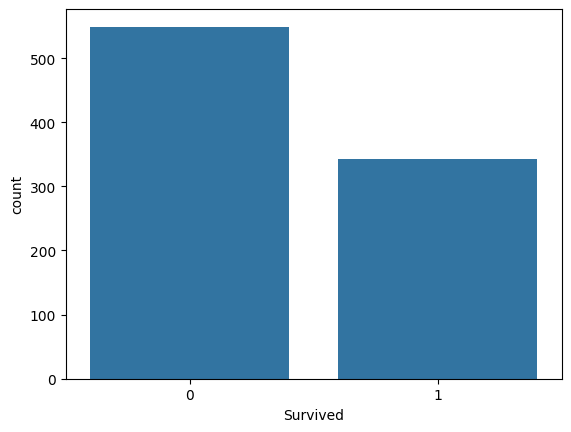

In [8]:
sns.countplot(x='Survived', data=df)
plt.show()

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [14]:
df = df.drop(columns=['Cabin'])

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

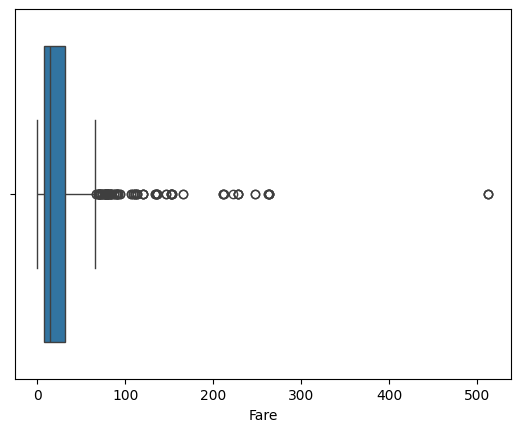

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Fare'])
plt.show()

In [17]:
df['Fare'] = df['Fare'].clip(
    lower=df['Fare'].quantile(0.05),
    upper=df['Fare'].quantile(0.95)
)

In [18]:
df.to_csv("../data/titanic_clean.csv", index=False)

In [20]:
df.select_dtypes(include=['object', 'string']).columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [21]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [23]:
df.drop(columns=['Name', 'Ticket'], inplace=True)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

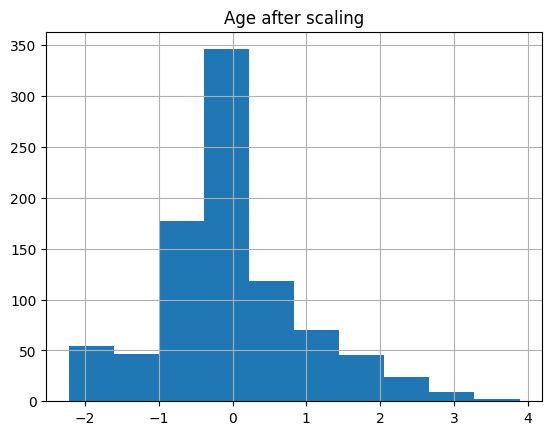

In [25]:
import matplotlib.pyplot as plt

df['Age'].hist()
plt.title("Age after scaling")
plt.show()

In [26]:
df.to_csv("../data/titanic_transformed.csv", index=False)

In [27]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

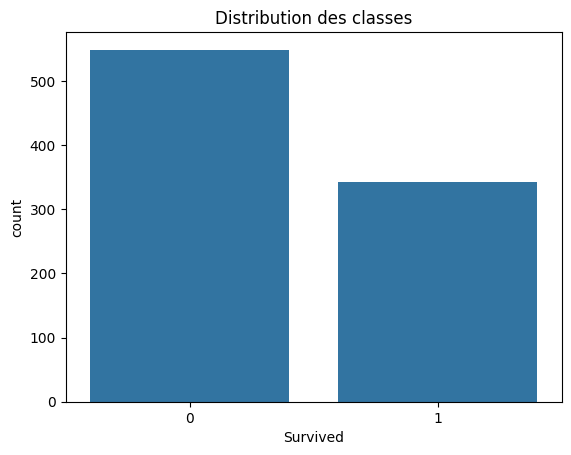

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Distribution des classes")
plt.show()

In [29]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

In [31]:
import pandas as pd

pd.Series(y_res).value_counts()

Survived
0    549
1    549
Name: count, dtype: int64

In [32]:
df_res = pd.concat([pd.DataFrame(X_res), pd.DataFrame(y_res, columns=['Survived'])])
df_res.to_csv("../data/titanic_final.csv", index=False)